In [1]:
import sys
!{sys.executable} -m pip install gensim matplotlib pandas numpy scikit-learn plotly streamlit

In [2]:
import os
import pandas as pd
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt 

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module='gensim')


In [3]:
# Load the preprocessed complaints data into a DataFrame

df = pd.read_csv('../data/complaints_processed_full.csv')
df.head()



,product,narrative
0,credit_reporting,account
1,credit_reporting,wrote three request unverified account listed ...
2,credit_reporting,recently going check new car carefully conside...
3,mortgages_and_loans,call hour weekend using various number
4,credit_reporting,notified experian inaccuracy report national c...


In [4]:
# Create a list of tokenized narratives

tokenized = df['narrative'].str.split().tolist()


In [5]:
# Build GenSim dictionary and corpus for topic modeling
dictionary = corpora.Dictionary(tokenized)
corpus = [dictionary.doc2bow(text) for text in tokenized]

In [6]:
# Evaluate coherence scores for different numbers of topics to select the optimal number of topics

candidate_topics = [5, 10, 15, 20, 25, 30]
coherence_scores = []

for k in candidate_topics:
    lda_model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10
    )
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=tokenized,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_scores.append(coherence_model.get_coherence())
    print(f"num_topics={k}, coherence={coherence_scores[-1]:.4f}")

num_topics=5, coherence=0.5259
num_topics=10, coherence=0.5313
num_topics=15, coherence=0.5291
num_topics=20, coherence=0.5263
num_topics=25, coherence=0.5039


KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (6,) and (5,)

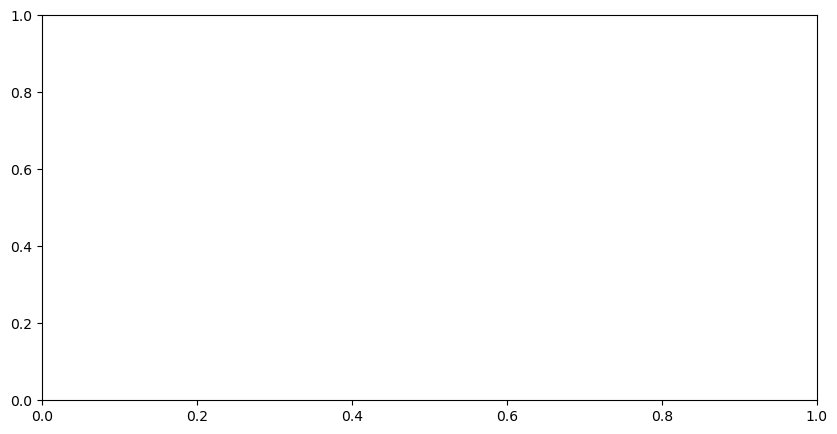

In [ ]:
# Plot coherence scores to visualize the optimal number of topics

plt.figure(figsize=(10, 5))
plt.plot(candidate_topics, coherence_scores, marker='o')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score (c_v)')
plt.title('LDA Coherence Score by Number of Topics')
plt.xticks(candidate_topics)
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Train the final LDA model using the optimal number of topics based on coherence scores

optimal_k = candidate_topics[coherence_scores.index(max(coherence_scores))]
print(f"Selected num_topics: {optimal_k}")

lda_final = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=optimal_k,
    random_state=42,
    passes=10
)

Selected num_topics: 10


KeyboardInterrupt: 

In [ ]:
# Inspect topic-word distributions

for idx, topic in lda_final.print_topics(num_words=10):
    print(f"Topic {idx}: {topic}")

In [ ]:
# Extract document-topic vectors and assign dominant topic to each document

import numpy as np

def get_doc_topic_vector(bow, model, num_topics):
    topic_dist = dict(model.get_document_topics(bow, minimum_probability=0.0))
    return [topic_dist.get(i, 0.0) for i in range(num_topics)]

topic_vectors = np.array([
    get_doc_topic_vector(bow, lda_final, optimal_k)
    for bow in corpus
])

topic_df = pd.DataFrame(
    topic_vectors,
    columns=[f'topic_{i}' for i in range(optimal_k)]
)
topic_df.head()

In [ ]:
import os
os.makedirs('../outputs', exist_ok=True)
 
topic_df.to_csv('../outputs/topic_vectors.csv', index=False)
print(f"Saved: outputs/topic_vectors.csv  shape={topic_df.shape}")
 
# Also save dominant topic per document
topic_df['dominant_topic'] = topic_df.values.argmax(axis=1)
df_with_topics = df.copy()
df_with_topics['dominant_topic'] = topic_df['dominant_topic'].values
df_with_topics.to_csv('../outputs/complaints_with_topics.csv', index=False)
print(f"Saved: outputs/complaints_with_topics.csv")

In [ ]:
mapping = df_with_topics.groupby(['dominant_topic', 'product']).size().unstack(fill_value=0)
mapping_pct = mapping.div(mapping.sum(axis=1), axis=0).round(3)
 
print("Topic → Product Category Distribution (%):")
print(mapping_pct.to_string())
 
import matplotlib.pyplot as plt
import seaborn as sns
 
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(mapping_pct, annot=True, fmt='.2f', cmap='Blues', ax=ax)
ax.set_title('Topic-to-Product Category Mapping')
ax.set_xlabel('Product Category')
ax.set_ylabel('Dominant Topic')
plt.tight_layout()
plt.savefig('../outputs/topic_category_heatmap.png', dpi=150)
plt.show()

In [ ]:
num_words = 10
fig, axes = plt.subplots(
    nrows=(optimal_k + 3) // 4,
    ncols=min(4, optimal_k),
    figsize=(16, 4 * ((optimal_k + 3) // 4))
)
axes = axes.flatten() if optimal_k > 1 else [axes]
 
for idx in range(optimal_k):
    top_words = lda_final.show_topic(idx, topn=num_words)
    words  = [w for w, _ in top_words]
    scores = [s for _, s in top_words]
    axes[idx].barh(words[::-1], scores[::-1], color='steelblue')
    axes[idx].set_title(f'Topic {idx}')
    axes[idx].set_xlabel('Weight')
 
# Hide unused subplots
for ax in axes[optimal_k:]:
    ax.set_visible(False)
 
plt.suptitle('Top Keywords per LDA Topic', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/topic_keywords.png', dpi=150)
plt.show()

In [ ]:
topic_labels = {i: f'Topic {i}' for i in range(optimal_k)}
 
# Example — edit these after inspecting the keyword charts:
# topic_labels = {
#     0: 'Credit Report Disputes',
#     1: 'Debt Collection Calls',
#     2: 'Mortgage Payments',
#     3: 'Card Fraud',
#     4: 'Account Access Issues',
#     ...
# }
 
import json
with open('../outputs/topic_labels.json', 'w') as f:
    json.dump(topic_labels, f, indent=2)
 
print("Saved: outputs/topic_labels.json")
print("Edit topic_labels dict above with descriptive names after reviewing keywords.")

In [ ]:
import os
model_dir = '../outputs/lda_model'
os.makedirs(model_dir, exist_ok=True)
lda_final.save(f'{model_dir}/lda_final.model')
dictionary.save(f'{model_dir}/dictionary.gensim')
print(f"Saved: outputs/lda_model/lda_final.model")
print(f"Saved: outputs/lda_model/dictionary.gensim")
print("\nTopic modelling complete. All outputs in outputs/")